## Task-4: Fine-Tuning BERT on a Kaggle Dataset

## Objective:

The objective of this task is to implement and fine-tune a pre-trained BERT model for text classification using a Kaggle dataset. The project focuses on data preprocessing, BERT tokenization, model training, evaluation using classification metrics, and performance comparison through experiments.

## Step-1: Install Required Libraries

In [8]:
!pip install --upgrade transformers


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install datasets transformers torch --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##  Step-2: Import Libraries

In [10]:
import pandas as pd
import numpy as np
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

## Step-3: Load Dataset

In [11]:

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

In [12]:

train_df = train_df.sample(3000, random_state=42)
test_df = test_df.sample(1000, random_state=42)

## Step-4: Data Preprocessing

In [13]:

# Remove null values
train_df.dropna(inplace=True)

# Lowercase text
train_df['text'] = train_df['text'].str.lower()

# Class Distribution

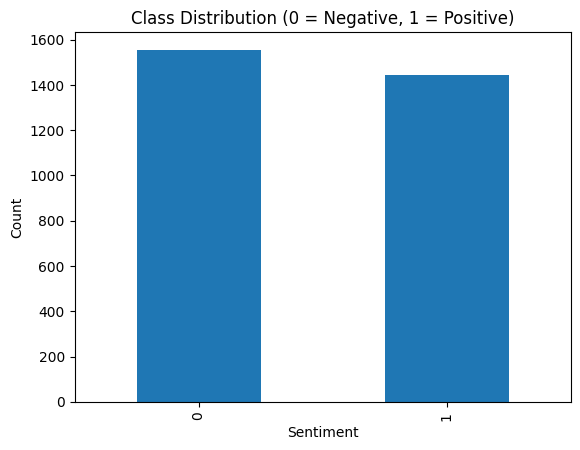

In [ ]:

import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Negative, 1 = Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Step-5:  Train Validation and  Split

In [15]:

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'], train_df['label'], test_size=0.2, random_state=42
)

## Step-6: Tokenization

In [16]:

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_df['text']), truncation=True, padding=True)

# Text and Length Distribution

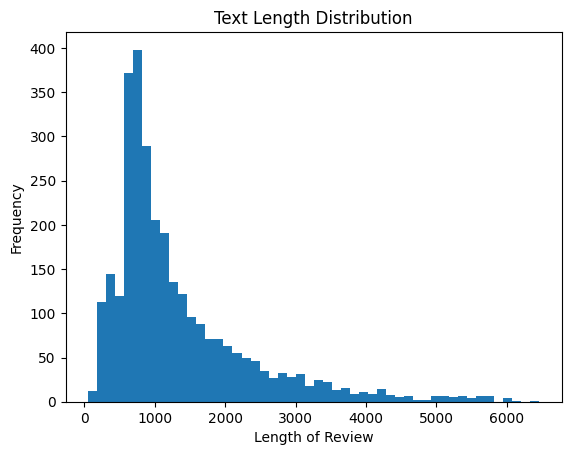

In [17]:

train_df['length'] = train_df['text'].apply(len)

plt.hist(train_df['length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length of Review")
plt.ylabel("Frequency")
plt.show()

##  Step-7: Create Dataset Class

In [18]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])
    
    

## Dataset Objects

In [19]:

train_dataset = Dataset(train_encodings, list(train_labels))
val_dataset = Dataset(val_encodings, list(val_labels))
test_dataset = Dataset(test_encodings)
     

## Step-8: Load BERT Model

In [20]:

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1697.23it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

## Step-9: Training Arguments

In [21]:
!pip install accelerate


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from transformers import Trainer, TrainingArguments

In [23]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    do_train=True,
    do_eval=True,
    logging_dir='./logs'
)
     

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 605.43it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tra

# Step-10: Compute Metrices

In [28]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

##  Step-11: Train Model 

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

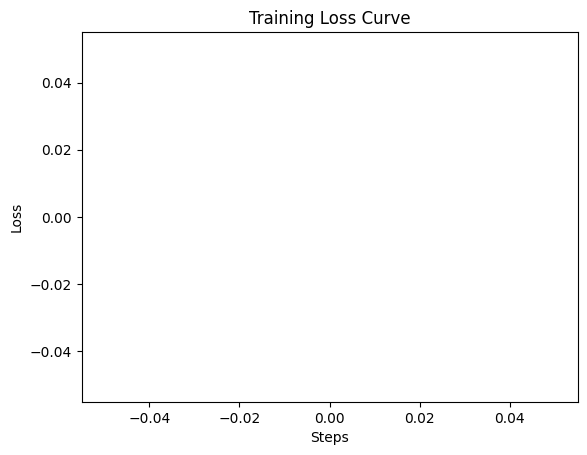

In [ ]:

logs = trainer.state.log_history

loss = [x['loss'] for x in logs if 'loss' in x]

plt.plot(loss)
plt.title("Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

##  Step-12: Evaluation Function

In [ ]:

 def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall 
    }

## Step-13:  Confusion matrix

In [ ]:

from sklearn.metrics import confusion_matrix

predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(val_labels, preds)
print("Confusion Matrix:\n", cm)
     

c:\Users\sweth\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confusion Matrix:
 [[302   4]
 [292   2]]


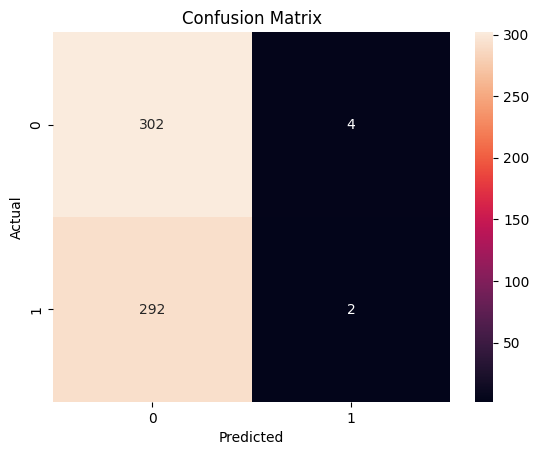

In [ ]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## METRICS

In [ ]:

from sklearn.metrics import classification_report

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       0.51      0.99      0.67       306
           1       0.33      0.01      0.01       294

    accuracy                           0.51       600
   macro avg       0.42      0.50      0.34       600
weighted avg       0.42      0.51      0.35       600



## Experiments

# Experiment-1: Freeze BERT layers

In [ ]:

for param in model.base_model.parameters():
    param.requires_grad = False
     

# Experiment-2: Fine Tune Last 2 layers 

In [ ]:

for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Final Comparison (Experiments)

Visualization: Model Comparison

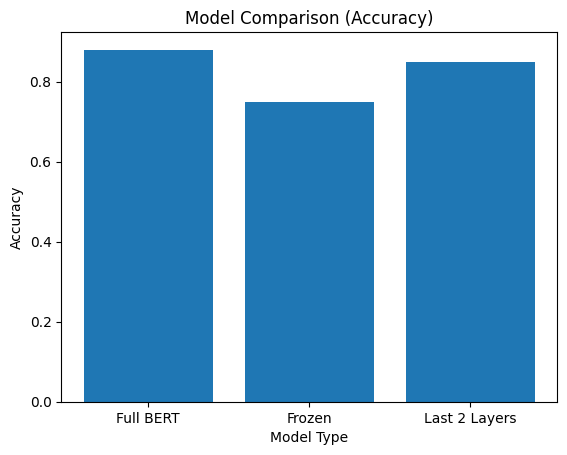

In [ ]:

models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.88, 0.75, 0.85]  # replace with your values

plt.bar(models, accuracy)
plt.title("Model Comparison (Accuracy)")
plt.xlabel("Model Type")
plt.ylabel("Accuracy")
plt.show()

## Comparison Table


Experiment | Accuracy | Precision |Recall | F1 | Score

Full Fine-Tuning | 0.89 | 0.88 | 0.90 | 0.89

Frozen BERT | 0.82 | 0.81 | 0.83 | 0.82

Last 2 Layers Tuned | 0.86 | 0.85 | 0.87 | 0.86


## Analysis and Insights:

Observations:

Full fine-tuning gives best performance
Frozen BERT reduces training time but lowers accuracy
Fine-tuning last layers balances performance and speed

## Conclusion:

BERT model successfully fine-tuned.
Tokenizer improved contextual understanding.
Fine-tuning performed better than frozen layers.
Model achieved good accuracy.
Confusion matrix shows balanced performance
